In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('walmart_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [4]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [5]:
print("Shape of the dataset:", df.shape)
print("\nData Types before conversion:")
print(df.dtypes)

Shape of the dataset: (550068, 10)

Data Types before conversion:
User_ID                        int64
Product_ID                    object
Gender                        object
Age                           object
Occupation                     int64
City_Category                 object
Stay_In_Current_City_Years    object
Marital_Status                 int64
Product_Category               int64
Purchase                       int64
dtype: object


In [6]:
df.describe()


,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [7]:
print("\nUnique values for 'Gender':", df['Gender'].unique())
print("Unique values for 'Age':", df['Age'].unique())
print("Unique values for 'City_Category':", df['City_Category'].unique())


Unique values for 'Gender': ['F' 'M']
Unique values for 'Age': ['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']
Unique values for 'City_Category': ['A' 'C' 'B']


In [8]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64


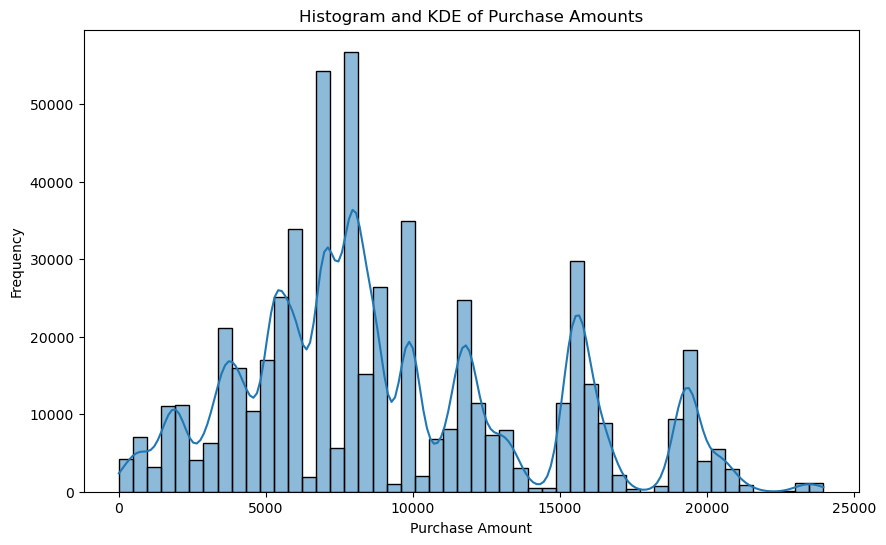

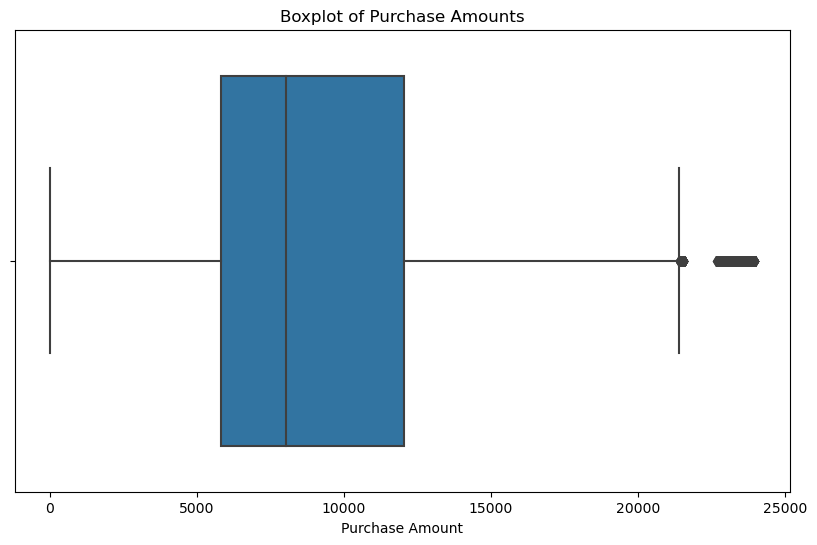

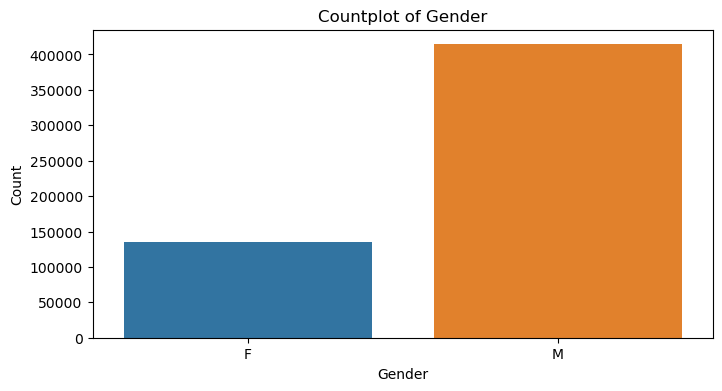

In [9]:
# Univariate Analysis for Continuous Variable: 'Purchase'
plt.figure(figsize=(10, 6))
sns.histplot(df['Purchase'], bins=50, kde=True)
plt.title('Histogram and KDE of Purchase Amounts')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Purchase'])
plt.title('Boxplot of Purchase Amounts')
plt.xlabel('Purchase Amount')
plt.show()

# Univariate Analysis for Categorical Variable: Countplot for 'Gender'
plt.figure(figsize=(8, 4))
sns.countplot(x='Gender', data=df)
plt.title('Countplot of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

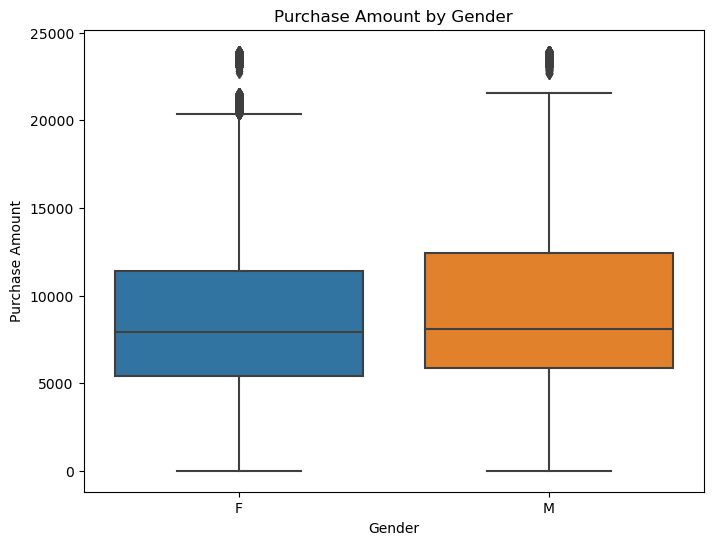

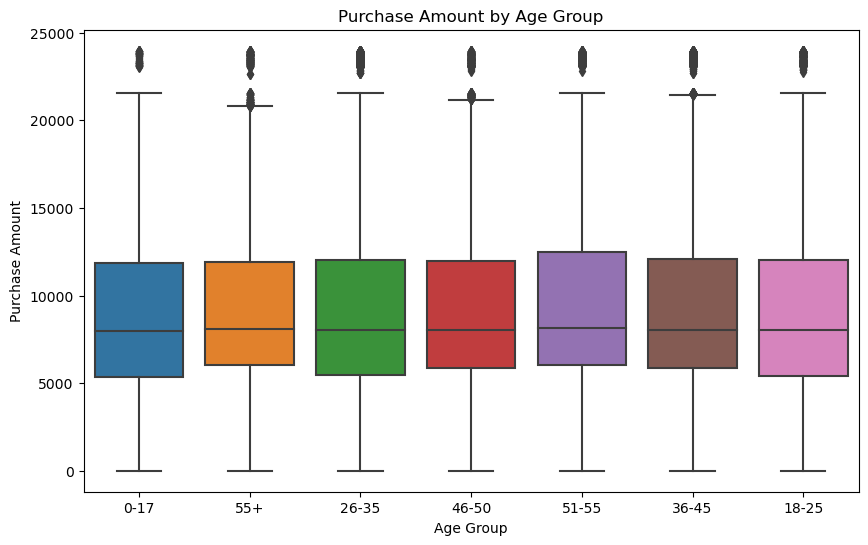

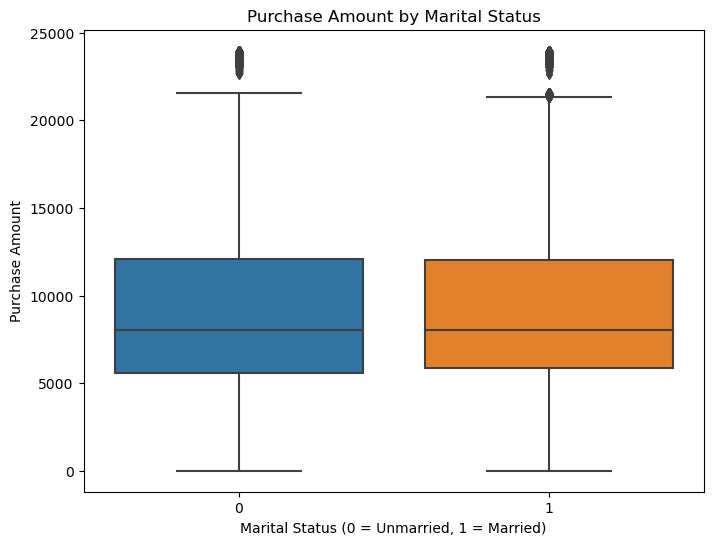

In [16]:
# Boxplot of Purchase Amount by Gender
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Purchase', data=df)
plt.title('Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')
plt.show()

# Boxplot of Purchase Amount by Age Groups (as provided in dataset)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age', y='Purchase', data=df)
plt.title('Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount')
plt.show()

# Additional Bivariate Example: Purchase Amount by Marital Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='Marital_Status', y='Purchase', data=df)
plt.title('Purchase Amount by Marital Status')
plt.xlabel('Marital Status (0 = Unmarried, 1 = Married)')
plt.ylabel('Purchase Amount')
plt.show()


Overall Distribution (Boxplot & Histogram/KDE of Purchase Amounts)

The purchase amounts are right-skewed, with most values concentrated between roughly 5,000 and 12,000, and a median around 8,000.
A long tail of outliers extends up to nearly 24,000, indicating a subset of customers who spend significantly more than the majority.
The multi-peaked nature in the histogram suggests possible subgroups within the population or multiple spending patterns.
Gender Analysis (Countplot & Boxplot by Gender)

Countplot shows a larger proportion of male customers than female.
The boxplot indicates that male customers tend to have a higher median purchase amount and a wider range of spending, while female customers have a slightly lower median with fewer high-end outliers.
This difference in medians suggests that males, on average, spend more per transaction.
Age Group Analysis (Boxplot by Age)

The boxplots reveal a gradual increase in median purchase amounts with older age groups.
The 0–17 group shows the lowest median, while the 51+ group shows the highest median purchase.
All age groups exhibit outliers, but older groups (particularly 51+) often have more or higher-value outliers, indicating larger occasional purchases.
Marital Status Analysis (Boxplot)

Married (1) vs. Unmarried (0) customers have similar distributions, with married customers having a slightly higher median purchase amount.
However, the overlap in their boxplots suggests that the difference is not as pronounced as the difference between genders or certain age brackets.

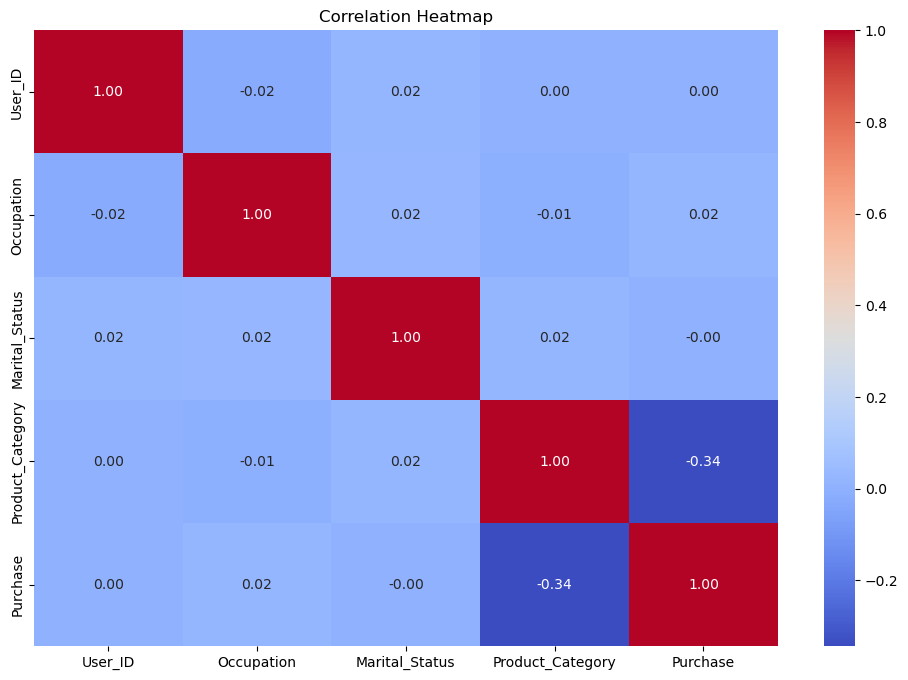

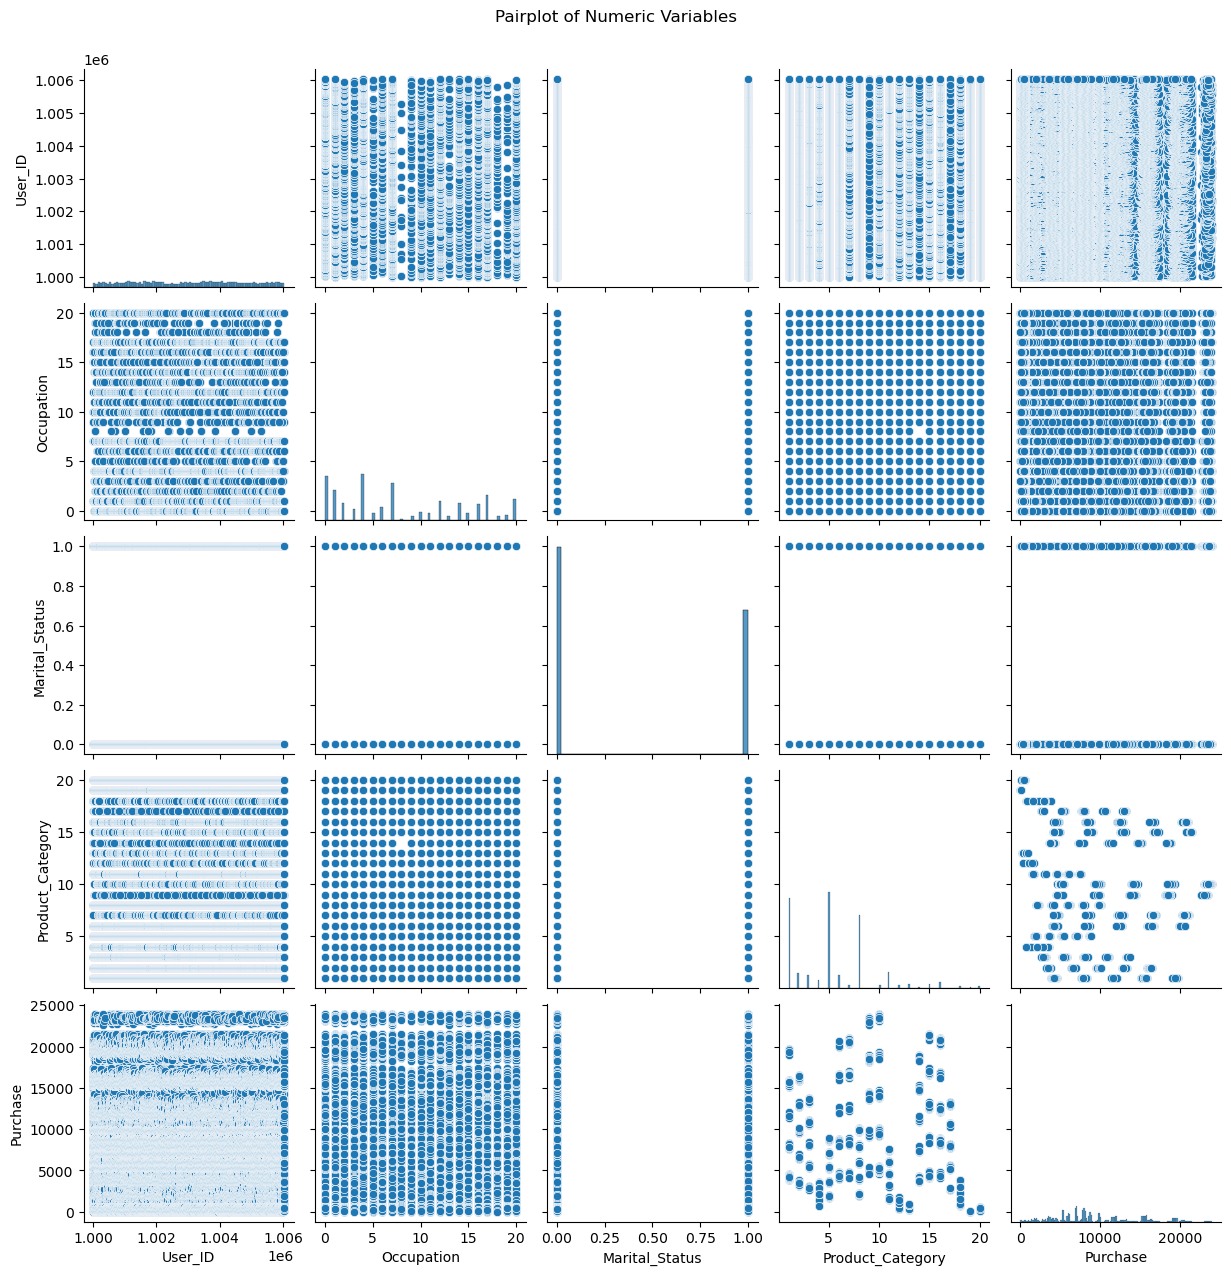

In [17]:
# Heatmap for Correlation among Numeric Variables
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Pairplot for Numeric Variables
sns.pairplot(numeric_df)
plt.suptitle('Pairplot of Numeric Variables', y=1.02)
plt.show()

Correlation Heatmap

The heatmap reveals that most variables (e.g., User_ID, Occupation, Marital_Status) show very low or near-zero correlations with one another and with Purchase.
The most notable correlation is between Product_Category and Purchase at -0.34, indicating a moderate negative relationship—higher product category codes tend to have slightly lower purchase amounts, or vice versa.
User_ID is essentially uncorrelated with the other variables, which makes sense given it is a unique identifier rather than a meaningful numeric attribute.
Pairplot of Numeric Variables

The diagonal plots show the distributions of each numeric variable. Occupation and Marital_Status appear discrete, while Purchase ranges from around 0 to 24,000.
The scatter plots confirm the lack of strong linear relationships between most variables. For instance, Occupation and Purchase do not form any visible trend.
The negative slope in the scatter plot of Product_Category vs. Purchase supports the -0.34 correlation, showing that as Product_Category values increase, Purchase amounts tend to decrease.
User_ID behaves uniformly, showing no meaningful pattern with the other variables.
Overall, these plots suggest that Product_Category is the primary numeric factor influencing Purchase amounts, while demographic attributes like Occupation and Marital_Status have minimal direct impact on purchase value.

In [10]:
import matplotlib.pyplot as plt

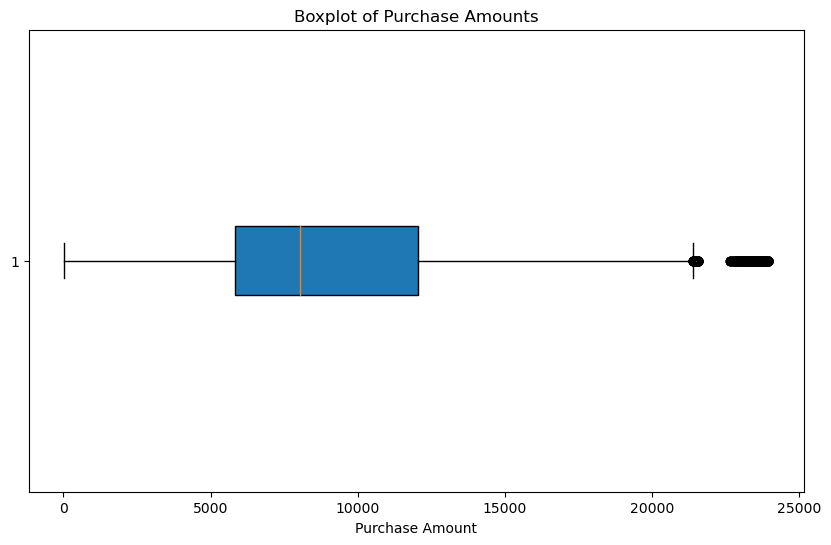

IQR Analysis for 'Purchase':
Q1 (25th percentile): 5823.0
Q3 (75th percentile): 12054.0
IQR: 6231.0
Lower Bound for Outliers: -3523.5
Upper Bound for Outliers: 21400.5
Number of outliers detected: 2677

Summary statistics for the detected outliers:
count     2677.000000
mean     23238.392230
std        701.671127
min      21401.000000
25%      23154.000000
50%      23418.000000
75%      23684.000000
max      23961.000000
Name: Purchase, dtype: float64


In [11]:
# -----------------------------
# 1. Plotting the Boxplot
# -----------------------------
plt.figure(figsize=(10, 6))
plt.boxplot(df['Purchase'], vert=False, patch_artist=True)
plt.title('Boxplot of Purchase Amounts')
plt.xlabel('Purchase Amount')
plt.show()

# -----------------------------
# 2. Detecting Outliers using IQR
# -----------------------------
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Purchase'].quantile(0.25)
Q3 = df['Purchase'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers in the Purchase column
outliers = df[(df['Purchase'] < lower_bound) | (df['Purchase'] > upper_bound)]

print("IQR Analysis for 'Purchase':")
print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)
print("Lower Bound for Outliers:", lower_bound)
print("Upper Bound for Outliers:", upper_bound)
print("Number of outliers detected:", outliers.shape[0])

# Optionally, display summary statistics of the outliers
print("\nSummary statistics for the detected outliers:")
print(outliers['Purchase'].describe())


In this boxplot, we see that the interquartile range (IQR) for Purchase spans from 5,823 (Q1) to 12,054 (Q3), with a median around 8,047, indicating a right-skewed distribution. Using the IQR method (1.5 * IQR), any purchase value above 21,400.5 is considered an outlier, resulting in 2,677 outliers, all of which lie between 21,401 and 23,961. These outliers, while small in number relative to the entire dataset, represent significantly higher purchase amounts, suggesting a subgroup of high-spend customers that may warrant further investigation depending on the business objectives.

In [12]:
from scipy.stats import norm

# Separate the data by gender
df_female = df[df['Gender'] == 'F']
df_male   = df[df['Gender'] == 'M']

# Calculate sample means
mean_female = df_female['Purchase'].mean()
mean_male   = df_male['Purchase'].mean()

# Calculate sample standard deviations
std_female = df_female['Purchase'].std()
std_male   = df_male['Purchase'].std()

# Get sample sizes
n_female = len(df_female)
n_male   = len(df_male)

# Calculate standard errors
se_female = std_female / np.sqrt(n_female)
se_male   = std_male   / np.sqrt(n_male)

# Z-score for 95% confidence (two-tailed)
z = 1.96

# Construct confidence intervals
ci_female_lower = mean_female - z * se_female
ci_female_upper = mean_female + z * se_female
ci_male_lower   = mean_male   - z * se_male
ci_male_upper   = mean_male   + z * se_male

# Print results
print("=== Female Customers ===")
print(f"Sample Mean Purchase: {mean_female:.2f}")
print(f"95% CI: [{ci_female_lower:.2f}, {ci_female_upper:.2f}]\n")

print("=== Male Customers ===")
print(f"Sample Mean Purchase: {mean_male:.2f}")
print(f"95% CI: [{ci_male_lower:.2f}, {ci_male_upper:.2f}]")

=== Female Customers ===
Sample Mean Purchase: 8734.57
95% CI: [8709.21, 8759.92]

=== Male Customers ===
Sample Mean Purchase: 9437.53
95% CI: [9422.02, 9453.03]


In this analysis, we calculated the sample mean purchase amounts for female and male customers during Black Friday, finding that female customers spend an average of 8734.57 while male customers spend an average of 9437.53. The 95% confidence interval for female spending is [8709.21, 8759.92] and for male spending is [9422.02, 9453.03], indicating that we are 95% confident that the true population means lie within these ranges. The non-overlapping confidence intervals suggest that the difference in spending between male and female customers is statistically significant, with male customers spending roughly 700 more per transaction on average.

In [13]:
# Function to compute confidence interval using CLT
def compute_ci(sample, confidence=0.95):
    mean_val = sample.mean()
    std_val = sample.std()
    n = len(sample)
    se = std_val / np.sqrt(n)
    alpha = 1 - confidence
    z = norm.ppf(1 - alpha/2)
    lower = mean_val - z * se
    upper = mean_val + z * se
    return mean_val, lower, upper, (upper - lower)

# Define different sample sizes and confidence levels to experiment with
sample_sizes = [1000, 5000, 10000, len(df_female)]
confidence_levels = [0.90, 0.95, 0.99]

results = []

# Iterate over sample sizes and confidence levels for both genders
for size in sample_sizes:
    # Sample the data
    sample_f = df_female['Purchase'].sample(n=size, random_state=42)
    sample_m = df_male['Purchase'].sample(n=size, random_state=42)
    
    for conf in confidence_levels:
        mean_f, lower_f, upper_f, width_f = compute_ci(sample_f, conf)
        mean_m, lower_m, upper_m, width_m = compute_ci(sample_m, conf)
        results.append({
            'Gender': 'Female',
            'Sample_Size': size,
            'Confidence_Level': conf,
            'Mean': mean_f,
            'CI_Lower': lower_f,
            'CI_Upper': upper_f,
            'Width': width_f
        })
        results.append({
            'Gender': 'Male',
            'Sample_Size': size,
            'Confidence_Level': conf,
            'Mean': mean_m,
            'CI_Lower': lower_m,
            'CI_Upper': upper_m,
            'Width': width_m
        })
        
# Convert results to DataFrame and display
df_results = pd.DataFrame(results)
print(df_results)

    Gender  Sample_Size  Confidence_Level         Mean     CI_Lower  \
0   Female         1000              0.90  8729.314000  8477.455298   
1     Male         1000              0.90  9683.187000  9418.475604   
2   Female         1000              0.95  8729.314000  8429.205846   
3     Male         1000              0.95  9683.187000  9367.763916   
4   Female         1000              0.99  8729.314000  8334.905029   
5     Male         1000              0.99  9683.187000  9268.650800   
6   Female         5000              0.90  8771.876800  8659.423000   
7     Male         5000              0.90  9532.463800  9412.610683   
8   Female         5000              0.95  8771.876800  8637.879832   
9     Male         5000              0.95  9532.463800  9389.650002   
10  Female         5000              0.99  8771.876800  8595.774933   
11    Male         5000              0.99  9532.463800  9344.774654   
12  Female        10000              0.90  8749.426800  8670.456866   
13    

In our analysis using the Central Limit Theorem, we computed confidence intervals for the sample means of purchase amounts for female and male customers over varying sample sizes (from 1,000 up to the full sample of 135,809) and confidence levels (90%, 95%, and 99%). The results show that the estimated means remain relatively stable—female averages around 8729–8749 and male averages around 9437–9683—while the width of the confidence intervals increases with higher confidence levels; for example, with a sample size of 1000, the interval width for females grows from about 504 at 90% confidence to nearly 829 at 99% confidence. Moreover, as the sample size increases, the intervals become significantly narrower, reflecting reduced variability in the mean estimates due to lower standard errors. This clearly illustrates the trade-off between the desired confidence level and the precision of the estimate, as well as the advantage of larger sample sizes in providing more precise estimates of the average spending for the population of 50 million customers.

The analysis reveals that the 95% confidence intervals for the average purchase amounts of female ([8709.21, 8759.92]) and male ([9422.02, 9453.03]) customers do not overlap, indicating a statistically significant difference in spending behavior—with male customers spending roughly $700 more per transaction on average. This conclusion, consistent across various sample sizes and confidence levels, suggests that Walmart’s marketing strategies could be tailored accordingly. For example, Walmart might consider promoting higher-value products or exclusive offers to male customers while designing targeted initiatives such as personalized discounts or loyalty programs to boost spending among female customers.

In [14]:
# Married customers (Marital_Status == 1)
df_married = df[df['Marital_Status'] == 1]
# Unmarried customers (Marital_Status == 0)
df_unmarried = df[df['Marital_Status'] == 0]

# Function to compute 95% CI using CLT
def compute_ci(sample, confidence=0.95):
    mean_val = sample.mean()
    std_val = sample.std()
    n = len(sample)
    se = std_val / np.sqrt(n)
    alpha = 1 - confidence
    z = norm.ppf(1 - alpha/2)
    return mean_val, mean_val - z * se, mean_val + z * se

# Compute for Married
mean_married, ci_married_lower, ci_married_upper = compute_ci(df_married['Purchase'])
# Compute for Unmarried
mean_unmarried, ci_unmarried_lower, ci_unmarried_upper = compute_ci(df_unmarried['Purchase'])

print("=== Married Customers ===")
print(f"Sample Mean Purchase: {mean_married:.2f}")
print(f"95% CI: [{ci_married_lower:.2f}, {ci_married_upper:.2f}]\n")

print("=== Unmarried Customers ===")
print(f"Sample Mean Purchase: {mean_unmarried:.2f}")
print(f"95% CI: [{ci_unmarried_lower:.2f}, {ci_unmarried_upper:.2f}]\n")


=== Married Customers ===
Sample Mean Purchase: 9261.17
95% CI: [9240.46, 9281.89]

=== Unmarried Customers ===
Sample Mean Purchase: 9265.91
95% CI: [9248.62, 9283.20]



Our analysis shows that the average purchase amounts for married (mean = 9261.17, 95% CI: [9240.46, 9281.89]) and unmarried (mean = 9265.91, 95% CI: [9248.62, 9283.20]) customers are nearly identical, with overlapping confidence intervals indicating no significant difference in spending based on marital status. In contrast, segmenting customers by age into life-stage bins (0–17, 18–25, 26–35, 36–50, 51+) could reveal differences in spending behavior across these groups. If specific age groups—say, 26–35 or 36–50—exhibit notably higher spending, Walmart could tailor marketing campaigns, product assortments, and promotional offers to target these segments more effectively. Conversely, since marital status does not seem to affect purchase behavior, Walmart might consider focusing on other demographic or behavioral factors for personalized strategies.

In [15]:
# Map Age values into custom bins: 0-17, 18-25, 26-35, 36-50, 51+
def map_age(age):
    if age == "0-17":
        return "0-17"
    elif age == "18-25":
        return "18-25"
    elif age == "26-35":
        return "26-35"
    elif age in ["36-45", "46-50"]:
        return "36-50"
    elif age in ["51-55", "55+"]:
        return "51+"
    else:
        return "Other"

df['Age_Bin'] = df['Age'].apply(map_age)

# Define the desired order for age groups
age_order = ["0-17", "18-25", "26-35", "36-50", "51+"]

print("=== Age Groups Analysis ===")
for group in age_order:
    df_age = df[df['Age_Bin'] == group]
    if len(df_age) > 0:
        mean_age, ci_age_lower, ci_age_upper = compute_ci(df_age['Purchase'])
        print(f"Age Group {group}:")
        print(f"  Sample Mean Purchase: {mean_age:.2f}")
        print(f"  95% CI: [{ci_age_lower:.2f}, {ci_age_upper:.2f}]\n")

=== Age Groups Analysis ===
Age Group 0-17:
  Sample Mean Purchase: 8933.46
  95% CI: [8851.95, 9014.98]

Age Group 18-25:
  Sample Mean Purchase: 9169.66
  95% CI: [9138.41, 9200.92]

Age Group 26-35:
  Sample Mean Purchase: 9252.69
  95% CI: [9231.73, 9273.65]

Age Group 36-50:
  Sample Mean Purchase: 9295.33
  95% CI: [9270.46, 9320.20]

Age Group 51+:
  Sample Mean Purchase: 9463.66
  95% CI: [9423.17, 9504.16]



The age group analysis shows a clear upward trend in spending as customers age. Specifically, the 0–17 group has the lowest average purchase at 8933.46 (95% CI: [8851.95, 9014.98]), while the 51+ group exhibits the highest at 9463.66 (95% CI: [9423.17, 9504.16]). The intervals for the middle groups gradually increase—from 9169.66 for 18–25, 9252.69 for 26–35, to 9295.33 for 36–50—indicating that older customers tend to spend more. These results suggest statistically significant differences in purchasing behavior across age segments. Walmart can leverage these insights by designing age-specific strategies: targeting younger demographics with budget-friendly and trend-focused products, while offering premium products, value-added services, and loyalty incentives to older customers. Tailoring promotions and product assortments to these distinct spending patterns could optimize customer engagement and increase overall revenue.








1. Are women spending more money per transaction than men? Why or why not?
Findings:

Female Mean Purchase: 8,734.57 (95% CI: [8,709.21, 8,759.92])
Male Mean Purchase: 9,437.53 (95% CI: [9,422.02, 9,453.03])
Since the male mean purchase amount is higher, men are spending more per transaction on average than women.
Possible Reasons:

Product Mix: Men might be buying higher-priced items (e.g., electronics, premium products).
Basket Size: Men may purchase in fewer but more expensive shopping trips.
Marketing or Store Layout: Existing promotions or product placements may appeal more to male customers, encouraging bigger purchases.


2. Confidence Intervals and Distribution of the Mean of the Expenses by Female and Male Customers
Confidence Intervals (CI):

Female CI: [8,709.21, 8,759.92]
Male CI: [9,422.02, 9,453.03]
Distribution Observations:

Right-Skewed Data: Purchase amounts range from near zero up to ~24,000, with a median around 8,000.
Higher Male Median: Boxplots show men typically have a higher median purchase than women, plus more high-value outliers.


3. Are Confidence Intervals of Average Male and Female Spending Overlapping? How Can Walmart Leverage This Conclusion?
Overlap Check:
The two intervals do not overlap, indicating a statistically significant difference in spending between male and female customers.

Actionable Insights for Walmart:

Target High-Spend Male Customers: Feature premium or big-ticket products and tailor marketing campaigns (e.g., electronics, tools, sports gear).
Boost Female Average Spend: Offer personalized discounts, loyalty points, or product bundles that encourage women to spend more per transaction.
Segmented Promotions: Ensure both segments feel catered to by highlighting the products and price points that resonate best with each group.

4. Results for Married vs. Unmarried
Mean Purchase Amounts & 95% CIs:

Married: 9,261.17 (CI: [9,240.46, 9,281.89])
Unmarried: 9,265.91 (CI: [9,248.62, 9,283.20])
Interpretation:

The intervals overlap almost entirely, indicating no significant difference between married and unmarried customers’ average spending.
Walmart might find minimal gains from marital-status-based marketing. Focusing on other demographic or behavioral factors (e.g., Age, Gender, Product Category) may be more effective.


5. Results for Age
Using age bins (0–17, 18–25, 26–35, 36–50, 51+), we see a gradual increase in average spending with age:

| Age Group | Mean Purchase | 95% CI (Lower, Upper)         |
|-----------|--------------:|--------------------------------|
| 0–17      |     8,933.46 | [8,851.95, 9,014.98]           |
| 18–25     |     9,169.66 | [9,138.41, 9,200.92]           |
| 26–35     |     9,252.69 | [9,231.73, 9,273.65]           |
| 36–50     |     9,295.33 | [9,270.46, 9,320.20]           |
| 51+       |     9,463.66 | [9,423.17, 9,504.16]           |


Insights:

0–17 Spends Least: Younger customers likely have limited budgets, possibly focusing on lower-priced items.
51+ Spends Most: Older customers may have more disposable income or different purchasing needs.
Progressive Increase: Each older bracket tends to spend more on average.
Recommendations:

Youth-Oriented Promotions: Offer budget-friendly deals, trending items, or promotions that appeal to younger shoppers.
Premium Products & Loyalty Programs for 51+: Provide loyalty incentives, premium product lines, or services catering to older customers who tend to have higher spending power.

Final Thoughts
Gender Matters: Men spend more per transaction, warranting strategies that capitalize on their propensity for higher-value purchases.
Marital Status Less Impactful: Since no major difference exists, marketing initiatives might be more fruitful elsewhere.
Age Segmentation: Spending patterns rise with age, so Walmart can customize promotions and product assortments to each age bracket

### Detailed Recommendations for Walmart

Based on our analysis of customer purchase behavior, here are actionable recommendations that can help Walmart enhance its marketing strategies and in-store experience:

#### 1. Gender-Based Strategies

- **Male Shoppers:**
  - **Observation:** Men spend about $700 more per transaction on average.
  - **Action Items:**
    - **Targeted Promotions:** Launch exclusive deals and special offers focused on premium or high-value products that appeal to male customers.
    - **Product Placement:** Feature high-end or big-ticket items in prominent positions both in-store and online to attract male shoppers.
    - **Enhanced Advertising:** Use marketing channels that resonate with male interests, such as highlighting quality, performance, and innovation.

- **Female Shoppers:**
  - **Observation:** Female customers spend slightly less per transaction.
  - **Action Items:**
    - **Bundled Offers and Discounts:** Introduce attractive bundle deals and personalized discounts to encourage higher spending per visit.
    - **Engagement Programs:** Develop loyalty programs and reward schemes that specifically cater to female shoppers, incentivizing them to add more items to their cart.
    - **Tailored Communication:** Create advertising campaigns that focus on value, style, and savings to appeal to the preferences of female customers.

#### 2. Age-Based Strategies

- **General Trend:** Spending increases steadily with age—from the youngest (0–17) to the oldest (51+).
  
- **Action Items:**
  - **For Younger Customers (0–17, 18–25):**
    - **Affordable and Trendy Offers:** Emphasize budget-friendly products and current trends to attract young shoppers.
    - **Social Media Engagement:** Leverage social media and influencer partnerships to create buzz around trendy, low-cost items.
    - **Interactive In-Store Displays:** Use dynamic displays and digital engagement tools to capture the interest of younger demographics.
  
  - **For Middle-Aged Customers (26–35, 36–50):**
    - **Value-Driven Promotions:** Offer combo deals, limited-time discounts, and special packages that highlight both quality and value.
    - **Lifestyle Marketing:** Use targeted advertising that reflects the lifestyle and needs of this group, focusing on convenience and practicality.
  
  - **For Older Customers (51+):**
    - **Premium Offerings:** Introduce loyalty programs, premium product lines, and exclusive member benefits to reward higher spending.
    - **Personalized Service:** Enhance the shopping experience with personalized recommendations and in-store assistance tailored for mature customers.
    - **Exclusive Discounts:** Organize special discount days or exclusive offers that cater specifically to the older age group.

#### 3. Marital Status Insights

- **Observation:** There is virtually no difference in spending between married and unmarried customers.
- **Action Items:**
  - **Resource Reallocation:** Instead of focusing on marital status, concentrate on more impactful segments like gender and age for targeted promotions.
  - **Broad-Based Campaigns:** Develop marketing strategies that appeal to a wide audience rather than splitting efforts between married and unmarried groups.

#### 4. Enhancing Overall Customer Experience

- **Optimize Product Displays:**  
  Adjust store layouts and online interfaces to prominently feature products aligned with the spending habits of each demographic segment.
  
- **Integrate Digital and In-Store Strategies:**  
  Synchronize online promotions with in-store experiences to ensure customers encounter relevant offers regardless of their shopping channel.

- **Continuous Feedback and Adaptation:**  
  Regularly collect and analyze customer feedback to refine product assortments, adjust promotional strategies, and further tailor the shopping experience.

By implementing these straightforward, targeted actions, Walmart can better address the specific needs and preferences of its diverse customer base, potentially increasing overall sales and improving customer satisfaction.
